#**Capítulo** 6) Introdução ao Machine Learning



##6.1) Importação e visualização do banco de dados

In [2]:
# Importando as bibliotecas e adicionando o acesso ao Drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

%matplotlib inline
np.random.seed(0)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Importando os dados do drive e gerando as estatisticas do arquivo train.csv

df_test = pd.read_csv('/content/drive/MyDrive/test.csv')
df_train = pd.read_csv('/content/drive/MyDrive/train.csv')

df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df_train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
#Analisando o tipo de dado das colunas
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
#Verificando valores ausentes
df_train.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
# Criando dois novos DF contendo apenas os valores numéricos

df_train_num = df_train.select_dtypes(include=["number"])
df_test_num = df_test.select_dtypes(include=["number"])
df_train_num.head(10)
#df_test_num.head(10)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
5,6,0,3,NaN,0,0,8.4583
6,7,0,1,54.0,0,0,51.8625
7,8,0,3,2.0,3,1,21.0750
8,9,1,3,27.0,0,2,11.1333
9,10,1,2,14.0,1,0,30.0708


In [8]:
# Retirando os dados ausentes nos dois dataframes

df_train_num = df_train_num.dropna()
df_test_num = df_test_num.fillna(0)
df_train_num.head(10)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
6,7,0,1,54.0,0,0,51.8625
7,8,0,3,2.0,3,1,21.0750
8,9,1,3,27.0,0,2,11.1333
9,10,1,2,14.0,1,0,30.0708
10,11,1,3,4.0,1,1,16.7000


##6.2) Exploração do banco de dados

In [9]:
# Descobrindo a idade máxima e incluindo a coluna das faixas etárias

print(df_train_num["Age"].max())

f_etaria = ['(0-10)', '(10-20)', '(20-30)', '(30-40)', '(40-50)', '(50-60)', '(60-70)', '(70-80)']
limite_idade = [0, 10, 20, 30, 40, 50, 60, 70, 80]

df_train_num["Age Group"] = pd.cut(df_train_num["Age"], bins=limite_idade, labels=f_etaria)

80.0


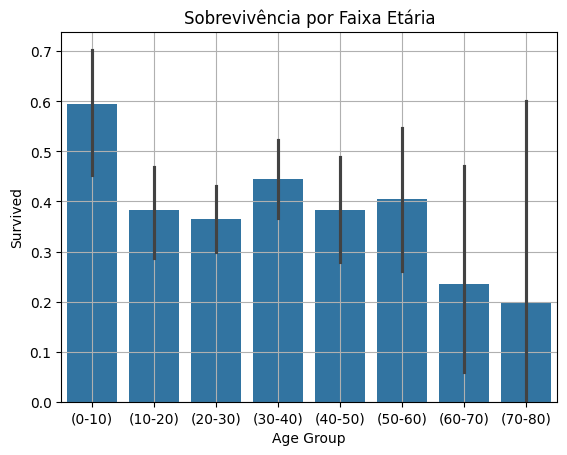

In [10]:
#Plotando o gráfico de barras da taxa de sobrevivência por faixa etária

sns.barplot(data=df_train_num, x="Age Group", y="Survived")
plt.title('Sobrevivência por Faixa Etária')
plt.grid(True)

Conseguimos entender um pouco a influência da idade na sobrevivência, as crianças podem ter sido priorizadas no resgate, pelo 'alto' índice de sobrevivência em relação aos demais, os adultos no geral seguiram uma linha parecida e os idosos talvez pela dificuldade na locomoção, pensando logicamente, teriam menos chances.

A não linearidade do grafico nas faixas etarias dos adultos é interessante, precisamos de mais dados para entendê-la, somente idade não é suficiente para tirar muitas conclusões.

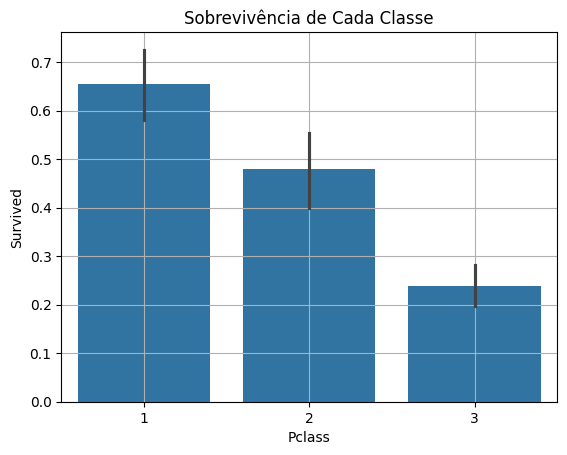

In [11]:
#Plotando o gráfico de barras da taxa de sobrevivência por classe
sns.barplot(data=df_train_num, x="Pclass", y="Survived")
plt.title('Sobrevivência de Cada Classe')
plt.grid(True)

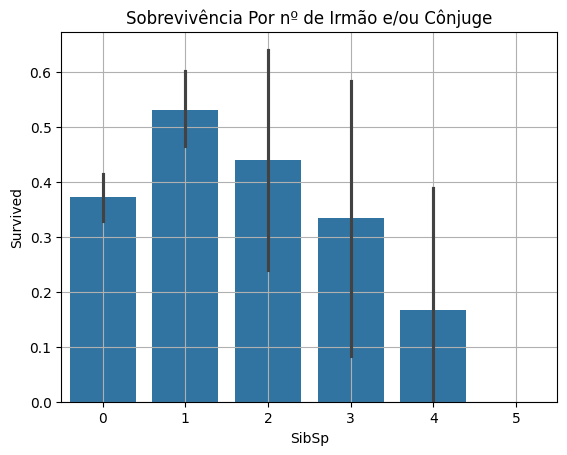

In [12]:
#Plotando o gráfico de barras da taxa de sobrevivência por nº de Irmão e/ou Cônjuge

sns.barplot(data=df_train_num, x="SibSp", y="Survived")
plt.title('Sobrevivência Por nº de Irmão e/ou Cônjuge')
plt.grid(True)

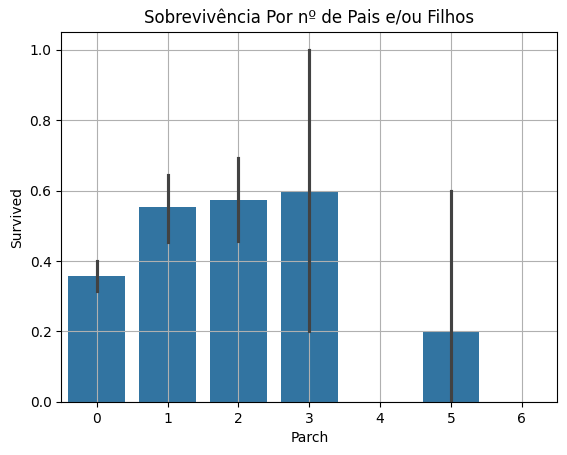

In [13]:
#Plotando o gráfico de barras da taxa de sobrevivência por nº de Pais e/ou Filhos

sns.barplot(data=df_train_num, x="Parch", y="Survived")
plt.title('Sobrevivência Por nº de Pais e/ou Filhos')
plt.grid(True)

Com os 4 parâmetros analisados, conseguimos supor mais coisas, entender melhor o impacto de cada uma das variáveis.

A primeira informação interessante é sobre a influência das classes da viagem, quanto mais barata a passagem, menor a chance de sobrevivência. Fiz uma pesquisa rápida na internet para entender mais sobre as classes no navio, a terceira classe era bem isolada das demais, nos níveis inferiores do navio, o que dificultou muito a chegada das pessoas aos botes salva-vidas, em contrapartida a primeira classe tinha acesso irrestrito a parte superior do navio, incluindo o local onde estavam os botes, o que nos leva a concluir que a classe teve influência direta na sobrevivência dos passageiros.

Traçando uma relação entre os dados dos gráficos, percebe-se que pessoas que viajaram sozinhas tinham chances próximas a 40%, chances boas, talvez pelo fato de não terem a obrigação de salvar mais ninguém. Famílias de médias a pequenas tiveram mais chances que famílias grandes, talvez pela dificuldade de encontrar mais pessoas do que famílias menores antes de ir até os botes salva-vidas, famílias menores tinham em quem se apoiar e precisavam de menos procura para encontrar todos ou a maioria dos integrantes antes de sair em segurança do navio

Essas foram as conclusões que eu cheguei, pela análise dos dados dos gráficos de barra plotados.

##6.3)Treinamento do modelo e submissão das predições

In [14]:
# Importando do sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Criando as variáveis X e y
X = df_train_num.drop(columns=["PassengerId", "Survived", "Age Group"])
y = df_train_num["Survived"]
#X.head(20)
#y.head(20)

# Separando os dados

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=0)

In [15]:
# Treinando o modelo com os dados de treino

model1 = RandomForestClassifier(random_state=0)
model1.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [16]:
# Precisão do modelo
y_pr = model1.predict(X_val)
precision = accuracy_score(y_val, y_pr)
precision

0.6713286713286714

67% é ok para o primeiro modelo, mas está longe de ser ideal, eu acho que por termos excluido muitas linhas por dados ausentes perdemos precisão. Provavelmente tem algum método mais inteligente de tratar esses dados.

In [17]:
# Agora com os dados de teste

p_id = df_test_num["PassengerId"]
X_test = df_test_num.drop(columns=["PassengerId"])
y_pred_test = model1.predict(X_test)

y_pred_test


array([0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,

In [18]:
# Criando o arquivo para submissão no kaggle:

submit = pd.DataFrame({"PassengerId": p_id, "Survived": y_pred_test})
#submit.head(10)
submit.to_csv("submit.csv", index=False)

submit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


No kaggle, o score ficou em 0,57655, por que essa diferença?? Tentar endender melhor

****
#**Capítulo 7)** Data Cleaning


##7.1)Análise Inicial

In [19]:
# Listando as colunas, identificando os tipos de dados delas e copiando os dataframes originais para preservar os dados

print(
    df_train.columns,"\n\n",
    df_test.columns, "\n"
)
print(
    df_train.info(), "\n",
    df_test.info()
)
train_clean = df_train.copy()
test_clean = df_test.copy()


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object') 

 Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: 

##7.2) Tratamento dos dados ausentes

Valores nulos nos dois DataFrames:

In [20]:
train_clean.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [21]:
test_clean.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


Tratando os dados ausentes:

In [22]:
# Retirando as colunas Cabin e Ticket
train_clean1 = train_clean.drop(columns=["Cabin", "Ticket"])
test_clean1 = test_clean.drop(columns=["Cabin", "Ticket"])

# Substituindo ausentes nas colunas de 'Age' e 'Fare' pela mediana e na coluna 'Embarked' pela moda

print(
    train_clean1["Age"].median(),"\n",
    test_clean1["Age"].median(), "\n\n",
    test_clean1["Fare"].median(),"\n\n",
    train_clean1["Embarked"].mode()[0]
)

train_clean1["Age"] = train_clean1["Age"].fillna(train_clean1["Age"].median())
test_clean1["Age"] = test_clean1["Age"].fillna(test_clean1["Age"].median())

test_clean1["Fare"] = test_clean1["Fare"].fillna(test_clean1["Fare"].median())

train_clean1["Embarked"] = train_clean1["Embarked"].fillna(train_clean1["Embarked"].mode()[0])


#train_clean1.isnull().sum()
#test_clean1.isnull().sum()



28.0 
 27.0 

 14.4542 

 S


##7.3)Criação de grupos a partir de variáveis contínuas

In [23]:
# dividindo as colunas em faixas de valores para 'Age' e 'Fare'

train_clean1["Age Group"] = pd.cut(train_clean1["Age"], bins=5)
test_clean1["Age Group"] = pd.cut(train_clean1["Age"], bins=5)

train_clean1["Fare group"] = pd.qcut(train_clean1["Fare"], q=6)
test_clean1["Fare group"] = pd.qcut(train_clean1["Fare"], q=6)


In [24]:
train_clean1["Fare group"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Fare group
Non-Null Count  Dtype   
--------------  -----   
891 non-null    category
dtypes: category(1)
memory usage: 1.3 KB


****


**Exercício Final: Reflexão sobre as escolhas de limpeza**

**1)** A primeira coisa que eu acho que se deve pensar é se a coluna é relevante, a coluna 'Ticket' não é muito útil pro modelo, não informa nada que influencia no resultado final, em quem sobrevive ou não.A coluna 'Cabin' talvez oferecesse informações interessantes, se tivermos o mapa das cabines, distância ate os botes salva vidas, mas tinham muitos dados ausentes, cerca de 3/4 é dado ausente, o que dificulta o aproveitamento desses dados no modelo.

**2)** O que eu julgo antes de escolher usar média ou mediana são os valores de máximo, minimo e alguns valores aleatórios da coluna, se tiver valores extremos, muito distantes de todos os outros, a mediana passa a ser uma ferramenta mais interessante, já que a média é muito influenciada pelos valores extremos, ficando distorcida, a mediana continua representando um valor mais próximo do 'centro' dos dados.

**3)** Pelo meu estudo, normalmente quando temos dados categóricos, ou seja, quando temos caracteres que representam um estado, uma caracteristica, como Male e Female por exemplo, usar a moda é interessante para preencher as lacunas, já que ela vai pegar o mais frequente e substituir os ausentes, é rápido e prático, mas fica ruim quando existem quantidades significativas de dados ausentes, daí podemos começar a direcionar inconscientemente o padrão aprendido pela máquina, tornando-a menos confiável.

**4)** Pelo que eu percebi durante a atividade, junto do gráfico feito no capítulo 6, é que utilizando de faixas etárias ao invés de idades e faixas de preço ao invés de preço unitário a interpretação dos gráficos fica mais fácil. Em alguns casos, esse agrupamento também pode facilitar a identificação de padrões pelo modelo, além de reduzir pequenas variações que contribuem pouco para a análise. O mesmo acontece com a variável Fare, passageiros com valores muito próximos passam a ser analisados juntos.
Contudo, inevitavelmente perdemos dados, passamos a tratar como iguais dados diferentes, então deixamos passar algumas coisas, essa é uma desvantagem.

**5)** O mais impactante foi não descartar as linhas com dados ausentes, como foi feito no capítulo anterior, procurar uma maneira mais eficiente para poder utilizar tudo de relevante que existe no banco de dados. Perdemos as informações de muitas pessoas nos dados de treino do capítulo 6 por simplesmente descartarmos as linhas com dados ausentes.

**6)**
 - Copiar os dados para não perder o banco de dados bruto
 - Escolher as features dentre as colunas e o target do problema
 - Verificar o tipo de dado de cada coluna
 - Padronizar os dados e tratar os ausentes
 - Conferir o conteúdo do banco de dados e começar para o treinamento do modelo

****

#**Capítulo 8)** Aperfeiçoamento da modelagem

In [25]:
#Importando do sklearn o que será utilizado no capítulo
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier


##8.1)Encoding de Variáveis Categóricas

In [26]:
# Reavaliando o tipo dos dados de cada coluna do banco de dados

train_clean1.info()
print('\n')
test_clean1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Fare         891 non-null    float64 
 9   Embarked     891 non-null    object  
 10  Age Group    891 non-null    category
 11  Fare group   891 non-null    category
dtypes: category(2), float64(2), int64(5), object(3)
memory usage: 72.0+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  418 no

In [27]:
#obs: mudança no codigo: adicionei mais divisões e adicionei o labels=false para retornar valores numericos ao inves das strings dos intervalos, pra não precisar codificar

train_clean1["Age Group"] = pd.cut(train_clean1["Age"], bins=8, labels=False)
test_clean1["Age Group"] = pd.cut(test_clean1["Age"], bins=8, labels=False)
train_clean1["Fare group"] = pd.qcut(train_clean1["Fare"], q=6, labels=False)
test_clean1["Fare group"] = pd.qcut(test_clean1["Fare"], q=6, labels=False)

# removendo age, fare e name dos dois dataframes

train_clean2 = train_clean1.drop(columns=["Age", "Fare"])
test_clean2 = test_clean1.drop(columns=["Age", "Fare"])

#
categoricas_train = list(train_clean2.select_dtypes(include=["object","category"]).columns)
numericas_train = list(train_clean2.select_dtypes(include=["int64","float64"]).columns)
categoricas_test = list(test_clean2.select_dtypes(include=["object","category"]).columns)
numericas_test = list(test_clean2.select_dtypes(include=["int64","float64"]).columns)

categoricas_train, numericas_train, "", categoricas_test, numericas_test

(['Name', 'Sex', 'Embarked'],
 ['PassengerId',
  'Survived',
  'Pclass',
  'SibSp',
  'Parch',
  'Age Group',
  'Fare group'],
 '',
 ['Name', 'Sex', 'Embarked'],
 ['PassengerId', 'Pclass', 'SibSp', 'Parch', 'Age Group', 'Fare group'])

In [28]:

# criar função para one-hot

def aplicar_onehot_encoder(df, categoricas_nominais):

  # copia dos dados
  copia_cod = df.copy()

  #criando one hot
  encoder = OneHotEncoder(
      sparse_output=False, # não transformar em matriz
      handle_unknown="ignore", # zerar valor caso aparecça uma categoria nova
      dtype="int64"
  )
  # loop para preencher um novo df com as novas colunas criadas pelo encoder

  for coluna in categoricas_nominais:

    #condição para codificar a coluna
    if coluna in ["Embarked"]:

      #codificando a coluna
      dados = encoder.fit_transform(copia_cod[[coluna]])

      #df com as colunas novas
      colunas_novas = pd.DataFrame(dados,
                             columns=encoder.get_feature_names_out([coluna]),
                             index=copia_cod.index
                             )
      # juntando as novas colunas ao dataframe copia
      copia_cod = pd.concat([copia_cod, colunas_novas], axis=1)

      # retirando as categoricas depois da codificação
      copia_cod = copia_cod.drop(columns=coluna)
  return copia_cod


In [29]:
#testando as mudanças

testando = aplicar_onehot_encoder(train_clean2, categoricas_train)

testando.info()
testando.head(10)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PassengerId  891 non-null    int64 
 1   Survived     891 non-null    int64 
 2   Pclass       891 non-null    int64 
 3   Name         891 non-null    object
 4   Sex          891 non-null    object
 5   SibSp        891 non-null    int64 
 6   Parch        891 non-null    int64 
 7   Age Group    891 non-null    int64 
 8   Fare group   891 non-null    int64 
 9   Embarked_C   891 non-null    int64 
 10  Embarked_Q   891 non-null    int64 
 11  Embarked_S   891 non-null    int64 
dtypes: int64(10), object(2)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Age Group,Fare group,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,1,0,2,0,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,3,5,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,0,0,2,1,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,3,5,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,0,0,3,1,0,0,1
5,6,0,3,"Moran, Mr. James",male,0,0,2,1,0,1,0
6,7,0,1,"McCarthy, Mr. Timothy J",male,0,0,5,4,0,0,1
7,8,0,3,"Palsson, Master. Gosta Leonard",male,3,1,0,3,0,0,1
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,0,2,2,2,0,0,1
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,1,0,1,4,1,0,0


In [30]:
# criar função para label encoding(pelo que eu entendi, o ordinal encoding seria melhor, contudo, seguimos o caminho da apostila)

def aplicar_label_encoding(df, categoricas_ordinais):

  #copia dos dados
  copia_cod1 = df.copy()

  #cria o encorder
  lencoder = LabelEncoder()

  #loop para acessar as colunas
  for coluna in categoricas_ordinais:

    #condicional para acessar as features desejadas
    if coluna in ["Sex"]:

      #codificando a coluna
      copia_cod1[coluna] = lencoder.fit_transform(copia_cod1[coluna])

  return copia_cod1


In [31]:
#testando as modificações

testando2 = aplicar_label_encoding(testando, categoricas_train)
testando2.info()
testando2.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PassengerId  891 non-null    int64 
 1   Survived     891 non-null    int64 
 2   Pclass       891 non-null    int64 
 3   Name         891 non-null    object
 4   Sex          891 non-null    int64 
 5   SibSp        891 non-null    int64 
 6   Parch        891 non-null    int64 
 7   Age Group    891 non-null    int64 
 8   Fare group   891 non-null    int64 
 9   Embarked_C   891 non-null    int64 
 10  Embarked_Q   891 non-null    int64 
 11  Embarked_S   891 non-null    int64 
dtypes: int64(11), object(1)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Age Group,Fare group,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,1,0,2,0,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,1,0,3,5,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,0,0,2,1,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,1,0,3,5,0,0,1
4,5,0,3,"Allen, Mr. William Henry",1,0,0,3,1,0,0,1
5,6,0,3,"Moran, Mr. James",1,0,0,2,1,0,1,0
6,7,0,1,"McCarthy, Mr. Timothy J",1,0,0,5,4,0,0,1
7,8,0,3,"Palsson, Master. Gosta Leonard",1,3,1,0,3,0,0,1
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,0,2,2,2,0,0,1
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",0,1,0,1,4,1,0,0


In [32]:
# criando um df de features e um do target com o novo banco de dados.

X2 = testando2.drop(columns=["PassengerId", "Survived", "Name"])
y2 = testando2["Survived"]
X2.head(20)
y2.head(20)

# Separando os dados

X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y2, test_size=0.20, random_state=0)


In [33]:
#treinando o novo modelo com os df do passo anterior

model2 = RandomForestClassifier(random_state=0)
model2.fit(X2_train, y2_train)

RandomForestClassifier(random_state=0)

In [34]:
# Precisão do modelo
y2_pr = model2.predict(X2_val)
precision2 = accuracy_score(y2_val, y2_pr)
precision2

0.8379888268156425

##8.2)Pipelines

In [35]:
# voltando com o dataframe original
train_pline = df_train.drop(columns=["Cabin", "Ticket"])
test_pline = df_test.drop(columns=["Cabin", "Ticket"])
train_pline.info()
test_pline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Fare         891 non-null    float64
 9   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(3)
memory usage: 69.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex      

**Criando a função que cria a pipeline, cria o modelo e avalia a precisão**

In [36]:
def pipeline(data, encoder, model, numerical_imputer, categorical_imputer):

  #separando features de target
  X = data.drop(columns=["Survived", "Name", "PassengerId"])
  y = data["Survived"]

  #separando os dados de treino e validação
  X_treino, X_val, y_treino, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

  #separando as features numericas e categoricas e criando preprocessor
  f_numericas = X.select_dtypes(include=["int64", "float64"]).columns
  f_categoricas = X.select_dtypes(include=["object"]).columns


  #criando a pipeline para as features categoricas
  pline_categoricas = Pipeline([
      ('imputar', categorical_imputer),
      ('codificar', encoder)
  ])

  #preprocessor = pegar as numericas preencher os NaN, pegar categoricas, preencher os NaN e depois codificar
  preprocessor = ColumnTransformer([
      ('num', numerical_imputer, f_numericas),
      ('cat', pline_categoricas, f_categoricas)
  ])

  #pipeline para criar o modelo
  pipeline = Pipeline([
      ('preprocessar', preprocessor),
      ('modelo', model)
  ])

  #treinar e avaliar
  pipeline.fit(X_treino, y_treino)
  precisao = pipeline.score(X_val, y_val)

  return precisao

In [37]:
#Listas com as estratégias

imput_numericos = [
    ('média', SimpleImputer(strategy='mean')),
    ('mediana', SimpleImputer(strategy='median')),
    ('moda', SimpleImputer(strategy='most_frequent')),
    ('zero', SimpleImputer(strategy='constant', fill_value=0))
]
imput_categoricos = [
    ('moda', SimpleImputer(strategy='most_frequent')),
    ('desconhecido', SimpleImputer(strategy='constant', fill_value='Unknown'))
]
encoders = [
    ('Ordinal Encoder', OrdinalEncoder()),
    ('One Hot Encoder', OneHotEncoder(handle_unknown='ignore'))
]

Criando o loop para testar as possibilidades

In [38]:
tabela = []
modelo = []

#3 loops por termos 3 variações, podemos variar o imputer numerico, imputer categorico e o encoder

for nome_in, imputer_n in imput_numericos:
  for nome_ic, imputer_c in imput_categoricos:
    for nome_ec, encoder in encoders:
      percentual = (pipeline(train_pline, encoder, RandomForestClassifier(random_state=42), imputer_n, imputer_c)) * 100
      tabela.append({"Imputer Numérico": nome_in, "Imputer Categórico": nome_ic, "Encoder": nome_ec, "Precisão": percentual})

#transformando a lista de dicionarios(tabela) para dataframe
df_tabela = pd.DataFrame(tabela).sort_values('Precisão', ascending=False)
df_tabela

,Imputer Numérico,Imputer Categórico,Encoder,Precisão
11,moda,desconhecido,One Hot Encoder,86.033520
5,mediana,moda,One Hot Encoder,85.474860
9,moda,moda,One Hot Encoder,84.916201
1,média,moda,One Hot Encoder,84.357542
6,mediana,desconhecido,Ordinal Encoder,84.357542
12,zero,moda,Ordinal Encoder,84.357542
3,média,desconhecido,One Hot Encoder,84.357542
4,mediana,moda,Ordinal Encoder,83.798883
10,moda,desconhecido,Ordinal Encoder,83.798883
7,mediana,desconhecido,One Hot Encoder,83.798883


##8.3)Cross Validation e Gradient Boosting

In [39]:
# eu sei que o melhor modelo foi a linha 5
df_tabela.iloc[0], "--" ,df_tabela.iloc[1]

(Imputer Numérico                 moda
 Imputer Categórico       desconhecido
 Encoder               One Hot Encoder
 Precisão                     86.03352
 Name: 11, dtype: object,
 '--',
 Imputer Numérico              mediana
 Imputer Categórico               moda
 Encoder               One Hot Encoder
 Precisão                     85.47486
 Name: 5, dtype: object)

In [40]:
# criando uma função para receber banco de dados, modelo e parâmetros(imputers e encoder), depois treina o modelo e valida com cross validation

def validacao_cruzada(df, imputer_numerico, imputer_categorico, encoder, modelo):

  X = df.drop(columns=["Survived", "PassengerId", "Name"])
  y = df["Survived"]

  numericas = X.select_dtypes(include=["int64","float64"]).columns
  categoricas = X.select_dtypes(include=["object"]).columns

  #criando a pipeline para imputar e codificar os dados categoricos
  pline_categoricas = Pipeline([
      ('imputar', imputer_categorico),
      ('Codificar', encoder)
      ])

  #preprocessor, imputando e codificando as colunas
  preprocessar = ColumnTransformer([
      ('num', imputer_numerico, numericas),
      ('cat', pline_categoricas, categoricas)
  ])
  # pipeline para preprocessar e criar o modelo
  pline_modelo = Pipeline([
      ('preprocessor', preprocessar),
      ('modelo', modelo)
  ])

  #validação cruzada
  pontuacao = cross_val_score(
      pline_modelo,
      X,
      y,
      cv=5,
      scoring='accuracy'
  )
  return pontuacao




In [41]:
#chamando a funçao para random forest, gradient boost e comparando
compare = []
score_rf = validacao_cruzada(train_pline, imput_numericos[1][1], imput_categoricos[0][1], encoders[0][1], RandomForestClassifier(random_state=42))
compare.append(['RandomForestScore Cross_Validation', (score_rf.mean())*100])

score_gb = validacao_cruzada(train_pline, imput_numericos[1][1], imput_categoricos[0][1], encoders[0][1], GradientBoostingClassifier(random_state=42, n_iter_no_change=100))
compare.append(['GradientBoosting Cross_Validation', (score_gb.mean())*100])


In [45]:
compare_df = pd.DataFrame(compare, columns=["Modelo", "Precisão"])
compare_df


,Modelo,Precisão
0,RandomForestScore Cross_Validation,81.259180
1,GradientBoosting Cross_Validation,82.717344
